## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.

    End Goal: The primary objective is to develop a Phase-Aware Multimodal Action Classifier that can precisely identify high-dynamic human movements (e.g., falling, jumping, or striking) by predicting the Biomechanical Phase (Preparation vs. Impact) in real-time.

    The Predictive Target: The model outputs a Phase-Dependent Credibility Score. Instead of a static fusion weight, it predicts which "expert" (Vision vs. IMU) should dominate the inference at any given millisecond. The final output is a robust action label that remains accurate even during visual motion blur or sensor noise.

    Focus on Modal Divergence: The research focuses on the Temporal Heterogeneity between two streams:

    The Intent Stream (Vision): Dominates the Preparation Phase, capturing cortical-level motor planning and long-range spatial context.

    The Reflex Stream (Inertial): Dominates the Impact Phase, capturing spinal-level high-frequency transients and physical forces often invisible to cameras.


2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

    **ActionSense (MIT)**: Contains fine-grained daily activities with rich modalities (Egocentric Vision, Gaze, EMG, Tactile, IMU). It is ideal for analyzing the transition from planning to rhythmic execution.

    **HARMONIC (CMU/UW)**: Features sEMG, eye-tracking, and robot states during shared autonomy. It is perfect for inducing "Decision Friction" when a robot's assistance conflicts with human intent.

    **Berkeley MHAD / UTD-MHAD**: Provides a clean baseline for macro-actions with synced Vision, IMU, and high-precision Skeleton data.

    **Drawbacks**: Many classic datasets like Berkeley MHAD suffer from "Link Rot," where original servers are offline, requiring us to rely on mirrors. Furthermore, UTD-MHAD lacks physiological anchors (EMG/Gaze), necessitating a proxy approach using kinetic latency.


3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

    **Chosen Modalities:**

    Gaze / Egocentric Vision: Acts as the "Conscious Anchor." Humans almost always lock their gaze on a target before deliberate action.

    sEMG (Electromyography): Acts as the proxy for "Neural Intent" and "Reflexes," capturing motor unit firing before physical displacement occurs.

    IMU / Skeleton: Provides the precise "Physical Execution" results in 3D space.

    **Modalities Not Used:**

    Depth Maps: While available in UTD-MHAD, Skeleton data already provides sufficient 3D spatial structure. Depth videos introduce significant computational redundancy without adding unique information for cognitive latency analysis.

    Force Plates: Though scientifically accurate, they are fixed to lab environments. To ensure our model's portability for wearable tech, we rely on portable IMU/EMG instead.

4. What difficulties did you encounter in obtaining the data?

    **Multi-modal temporal misalignment:** The three modalities have different sampling rates: RGB video at ~30 fps, skeleton at ~30 fps, and the inertial sensor at 50 Hz — so the number of frames/samples per recording differs across modalities for the same action trial. Aligning them temporally for comparison required normalizing to a common time axis (0–100% action progress).

    **No built-in labels in data files:** The action labels are encoded only in the filename convention (a{i}_s{j}_t{k}_modality), not inside the data files themselves, so we had to parse filenames to extract metadata (action ID, subject, trial number) and map them to human-readable action names.


5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?

    **Representation:** Three very different formats (pixels vs time-series vs 3D coordinates). We extract fixed-length feature vectors from each to unify representations.

    **Alignment:** Different sampling rates (RGB 30fps, IMU 50Hz). We normalize to 0–100% action progress for temporal alignment.

    **Reasoning:** Complex actions require cross-modal reasoning — skeleton shows pose, IMU captures force, RGB provides context.

    **Generation:** Not applicable to our classification task, but would matter if extended to action prediction.

    **Transference:** A sensor may be missing at test time. Multi-modal training enables the model to still function with fewer modalities.

    **Quantification:** Our t-SNE shows IMU better separates explosive actions while skeleton better separates spatial gestures, confirming complementarity.

(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  

The primary challenge was the Sampling Rate Mismatch. Videos are recorded at a fixed low frame rate, whereas IMU sensors record at much higher frequencies (100Hz+). To synchronize these into a single multimodal tensor, we had to implement sliding window aggregation for the IMU data to ensure that the physical features aligned correctly with the corresponding video frames without losing the transient "spikes" that represent subconscious reflexes.


In [ ]:
!pip install opencv-python

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.io as sio
import cv2
import glob
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# 1. Mount Google Drive to access the dataset
DATASET_ROOT = '/content/drive/MyDrive/utd_mhad'

import os

# Auto-detect folder structure
if os.path.exists(os.path.join(DATASET_ROOT, 'Inertial')):
    SKELETON_DIR = os.path.join(DATASET_ROOT, 'Skeleton')
    INERTIAL_DIR = os.path.join(DATASET_ROOT, 'Inertial')
    # RGB may be split across RGB-part1, RGB-part2, etc.
    if os.path.exists(os.path.join(DATASET_ROOT, 'RGB')):
        RGB_DIRS = [os.path.join(DATASET_ROOT, 'RGB')]
    else:
        RGB_DIRS = sorted(glob.glob(os.path.join(DATASET_ROOT, 'RGB-part*')))
    print(f'Skeleton: {SKELETON_DIR}')
    print(f'Inertial: {INERTIAL_DIR}')
    print(f'RGB dirs: {RGB_DIRS}')
else:
    SKELETON_DIR = DATASET_ROOT
    INERTIAL_DIR = DATASET_ROOT
    RGB_DIRS = [DATASET_ROOT]
    print('Using flat folder structure')

def find_rgb_path(prefix):
    """Search across RGB-part1/2/3/4 folders for matching video."""
    for d in RGB_DIRS:
        p = os.path.join(d, f'{prefix}_color.avi')
        if os.path.exists(p):
            return p
    return None

# List a few files to verify
all_files = os.listdir(INERTIAL_DIR)[:10]
print(f'\nFiles in INERTIAL_DIR ({INERTIAL_DIR}):')
for f in sorted(all_files):
    print(f'  {f}')

# ====== Print-friendly matplotlib defaults ======
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 200
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor'] = 'white'
matplotlib.rcParams['savefig.facecolor'] = 'white'
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['figure.max_open_warning'] = 0
plt.style.use('default')  # clean white style for printing

# 27 action labels in UTD-MHAD
ACTION_LABELS = {
    1: 'Right arm swipe left', 2: 'Right arm swipe right', 3: 'Right hand wave',
    4: 'Two hand front clap', 5: 'Right arm throw', 6: 'Cross arms in chest',
    7: 'Basketball shoot', 8: 'Right hand draw X', 9: 'Draw circle CW',
    10: 'Draw circle CCW', 11: 'Draw triangle', 12: 'Bowling',
    13: 'Front boxing', 14: 'Baseball swing', 15: 'Tennis forehand',
    16: 'Arm curl', 17: 'Tennis serve', 18: 'Two hand push',
    19: 'Knock on door', 20: 'Catch object', 21: 'Pick up & throw',
    22: 'Jogging in place', 23: 'Walking in place', 24: 'Sit to stand',
    25: 'Stand to sit', 26: 'Forward lunge', 27: 'Squat',
}

print('All packages loaded!')


# ---- Modality 1: RGB Video Frame Extraction ----
# (Extended from the provided skeleton code)

# ---- Modality 1: RGB Video Frame Extraction ----
# (Extended from the provided skeleton code)

def extract_rgb_frames(video_path, max_frames=None, sample_rate=1):
    """
    Extract frames from an RGB video file (.avi).
    Based on the provided skeleton code, extended with sampling options.

    Args:
        video_path: path to .avi file
        max_frames: max number of frames to return (None = all)
        sample_rate: keep every N-th frame

    Returns:
        frames: list of numpy arrays (H, W, 3) in RGB
        total_frame_count: total frames in the video
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frame_count = 0

    if not cap.isOpened():
        print(f'  [ERROR] Cannot open: {video_path}')
        return frames, 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if total_frame_count % sample_rate == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
            if max_frames and len(frames) >= max_frames:
                break

        total_frame_count += 1

    cap.release()
    return frames, total_frame_count

print('RGB extraction function ready.')


# ---- Modality 2: Inertial Sensor (IMU) Extraction ----
# IMU data: 6 channels — 3-axis accelerometer + 3-axis gyroscope at 50 Hz
# Stored in .mat files with variable name 'd_iner'

def load_mat_safe(filepath):
    """Load .mat file, handling both MATLAB v5 and v7.3 (HDF5) formats."""
    try:
        return sio.loadmat(filepath)
    except NotImplementedError:
        import h5py
        data = {}
        with h5py.File(filepath, 'r') as f:
            for key in f.keys():
                data[key] = np.array(f[key])
        return data


def extract_inertial(mat_path):
    """
    Extract inertial sensor data from a .mat file.

    Returns:
        raw: (T, 6) array  [ax, ay, az, gx, gy, gz]
        features: dict of summary statistics
    """
    data = load_mat_safe(mat_path)

    # Find the data variable
    raw = None
    for key in ['d_iner', 'data', 'inertial']:
        if key in data:
            raw = np.array(data[key], dtype=np.float64)
            break
    if raw is None:
        for key in data:
            if not key.startswith('__'):
                raw = np.array(data[key], dtype=np.float64)
                break
    if raw is None:
        return None, None

    # Ensure shape (T, 6)
    if raw.shape[0] == 6 and raw.shape[1] != 6:
        raw = raw.T

    accel = raw[:, :3]   # acceleration (g)
    gyro  = raw[:, 3:]   # angular velocity (deg/s)
    accel_mag = np.linalg.norm(accel, axis=1)
    gyro_mag  = np.linalg.norm(gyro, axis=1)
    jerk = np.diff(accel, axis=0) * 50   # derivative × sampling rate
    jerk_mag = np.linalg.norm(jerk, axis=1)

    features = {
        'accel': accel, 'gyro': gyro,
        'accel_mag': accel_mag, 'gyro_mag': gyro_mag,
        'jerk_mag': jerk_mag,
        'peak_accel': np.max(accel_mag), 'mean_accel': np.mean(accel_mag), 'std_accel': np.std(accel_mag),
        'peak_gyro':  np.max(gyro_mag),  'mean_gyro':  np.mean(gyro_mag),  'std_gyro':  np.std(gyro_mag),
        'peak_jerk':  np.max(jerk_mag) if len(jerk_mag) > 0 else 0,
    }
    return raw, features

print('IMU extraction function ready.')


# ---- Modality 3: Skeleton Joint Position Extraction ----
# Skeleton: 20 joints × 3 coordinates (x, y, z) per frame from Kinect
# Stored in .mat files with variable 'd_skel'

JOINT_NAMES = [
    'HipCenter','Spine','ShoulderCenter','Head',
    'ShoulderLeft','ElbowLeft','WristLeft','HandLeft',
    'ShoulderRight','ElbowRight','WristRight','HandRight',
    'HipLeft','KneeLeft','AnkleLeft','FootLeft',
    'HipRight','KneeRight','AnkleRight','FootRight'
]

# Bone connections for drawing skeleton
SKELETON_CONNECTIONS = [
    (0,1),(1,2),(2,3),               # spine->head
    (2,4),(4,5),(5,6),(6,7),          # left arm
    (2,8),(8,9),(9,10),(10,11),       # right arm
    (0,12),(12,13),(13,14),(14,15),   # left leg
    (0,16),(16,17),(17,18),(18,19),   # right leg
]


def extract_skeleton(mat_path):
    """
    Extract skeleton joint positions from a .mat file.

    Returns:
        raw: (T, 20, 3) array
        features: dict of summary statistics and feature vector
    """
    data = load_mat_safe(mat_path)

    raw = None
    for key in ['d_skel', 'data', 'skeleton']:
        if key in data:
            raw = np.array(data[key], dtype=np.float64)
            break
    if raw is None:
        for key in data:
            if not key.startswith('__'):
                raw = np.array(data[key], dtype=np.float64)
                break
    if raw is None:
        return None, None

    # Reshape to (T, num_joints, 3)
    if raw.ndim == 2:
        T = raw.shape[0]
        n_joints = raw.shape[1] // 3
        raw = raw.reshape(T, n_joints, 3)
    elif raw.ndim == 3:
        if raw.shape[0] == 3:        # (3, 20, T)
            raw = raw.transpose(2, 1, 0)
        elif raw.shape[2] != 3:      # another layout
            raw = raw.transpose(2, 0, 1)

    T, n_joints, _ = raw.shape

    # Joint velocities
    velocities = np.diff(raw, axis=0)
    joint_speeds = np.linalg.norm(velocities, axis=2)  # (T-1, J)

    # Build a fixed-length feature vector for t-SNE
    mean_pose  = raw.mean(axis=0).flatten()         # (60,)
    std_pose   = raw.std(axis=0).flatten()          # (60,)
    mean_speed = joint_speeds.mean(axis=0) if len(joint_speeds)>0 else np.zeros(n_joints)
    max_speed  = joint_speeds.max(axis=0)  if len(joint_speeds)>0 else np.zeros(n_joints)

    features = {
        'joint_speeds': joint_speeds,
        'mean_pose': mean_pose,
        'std_pose': std_pose,
        'mean_speed': mean_speed,
        'max_speed': max_speed,
        'feature_vector': np.concatenate([mean_pose, std_pose, mean_speed, max_speed]),
    }
    return raw, features

print('Skeleton extraction function ready.')


def parse_filename(filename):
    """Parse UTD-MHAD filename convention: a{i}_s{j}_t{k}_modality.ext"""
    base = os.path.splitext(os.path.basename(filename))[0]
    parts = base.split('_')
    action  = int(parts[0][1:])   # a1 -> 1
    subject = int(parts[1][1:])   # s1 -> 1
    trial   = int(parts[2][1:])   # t1 -> 1
    return action, subject, trial


# --- Find all inertial .mat files as reference ---
inertial_files = sorted(glob.glob(os.path.join(INERTIAL_DIR, '*inertial*.mat')))
if not inertial_files:
    inertial_files = sorted(glob.glob(os.path.join(INERTIAL_DIR, '*_inertial.mat')))
if not inertial_files:
    # Maybe the files don't have 'inertial' in name, try all .mat
    inertial_files = sorted(glob.glob(os.path.join(INERTIAL_DIR, '*.mat')))

print(f'Found {len(inertial_files)} inertial files')
if inertial_files:
    print(f'Example: {os.path.basename(inertial_files[0])}')


# ====== SUBSET SELECTION ======
# Only pick a few representative actions × 1 trial per subject for speed.
# 8 actions × 8 subjects × 1 trial = ~64 files (fast on Colab + Drive)

SELECTED_ACTIONS = [3, 5, 7, 13, 14, 15, 22, 27]
# 3=wave, 5=throw, 7=basketball, 13=boxing, 14=baseball,
# 15=tennis, 22=jogging, 27=squat
# Mix of arm gestures, explosive sports, and full-body actions

MAX_TRIALS = 1  # 1 trial per (action, subject)

selected_files = []
trial_count = {}

for iner_path in inertial_files:
    action, subject, trial = parse_filename(iner_path)
    if action not in SELECTED_ACTIONS:
        continue
    key = (action, subject)
    trial_count.setdefault(key, 0)
    if trial_count[key] >= MAX_TRIALS:
        continue
    trial_count[key] += 1
    selected_files.append(iner_path)

print(f'Selected {len(selected_files)} / {len(inertial_files)} files')
print(f'Actions: {SELECTED_ACTIONS}')
print(f'(Edit SELECTED_ACTIONS or set MAX_TRIALS=4 to include more)')

# ---- Extract all three modalities from selected subset ----
records = []

for i, iner_path in enumerate(selected_files):
    action, subject, trial = parse_filename(iner_path)
    prefix = f'a{action}_s{subject}_t{trial}'

    # Corresponding files for other modalities
    skel_path = os.path.join(SKELETON_DIR, f'{prefix}_skeleton.mat')
    rgb_path  = find_rgb_path(prefix)

    record = {
        'action': action, 'subject': subject, 'trial': trial,
        'label': ACTION_LABELS.get(action, f'Action {action}'),
        'prefix': prefix,
    }

    # 1) Inertial
    raw_iner, iner_feats = extract_inertial(iner_path)
    if raw_iner is not None:
        record['iner_raw'] = raw_iner
        record['iner_feat'] = iner_feats

    # 2) Skeleton
    if os.path.exists(skel_path):
        raw_skel, skel_feats = extract_skeleton(skel_path)
        if raw_skel is not None:
            record['skel_raw'] = raw_skel
            record['skel_feat'] = skel_feats

    # 3) RGB — just store path, load on demand (saves RAM)
    if rgb_path is not None:
        record['rgb_path'] = rgb_path

    records.append(record)

    if (i+1) % 50 == 0:
        print(f'  Processed {i+1}/{len(selected_files)}...')

print(f'\nDone! Extracted {len(records)} samples.')
print(f'  With IMU data: {sum(1 for r in records if "iner_raw" in r)}')
print(f'  With Skeleton: {sum(1 for r in records if "skel_raw" in r)}')
print(f'  With RGB path: {sum(1 for r in records if "rgb_path" in r)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Skeleton: /content/drive/MyDrive/utd_mhad/Skeleton
Inertial: /content/drive/MyDrive/utd_mhad/Inertial
RGB dirs: ['/content/drive/MyDrive/utd_mhad/RGB-part1', '/content/drive/MyDrive/utd_mhad/RGB-part2', '/content/drive/MyDrive/utd_mhad/RGB-part3', '/content/drive/MyDrive/utd_mhad/RGB-part4']

Files in INERTIAL_DIR (/content/drive/MyDrive/utd_mhad/Inertial):
  a1_s1_t1_inertial.mat
  a1_s1_t2_inertial.mat
  a1_s1_t3_inertial.mat
  a1_s1_t4_inertial.mat
  a2_s1_t1_inertial.mat
  a2_s1_t2_inertial.mat
  a2_s1_t3_inertial.mat
  a2_s1_t4_inertial.mat
  a3_s1_t1_inertial.mat
  a3_s1_t2_inertial.mat
All packages loaded!
RGB extraction function ready.
IMU extraction function ready.
Skeleton extraction function ready.
Found 861 inertial files
Example: a10_s1_t1_inertial.mat
Selected 64 / 861 files
Actions: [3, 5, 7, 13, 14, 15, 22, 27]
(Edit SELECTED_ACTIONS or set MA

(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [ ]:
# Packages (feel free to include more if needed)!
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs

# Data Distribution

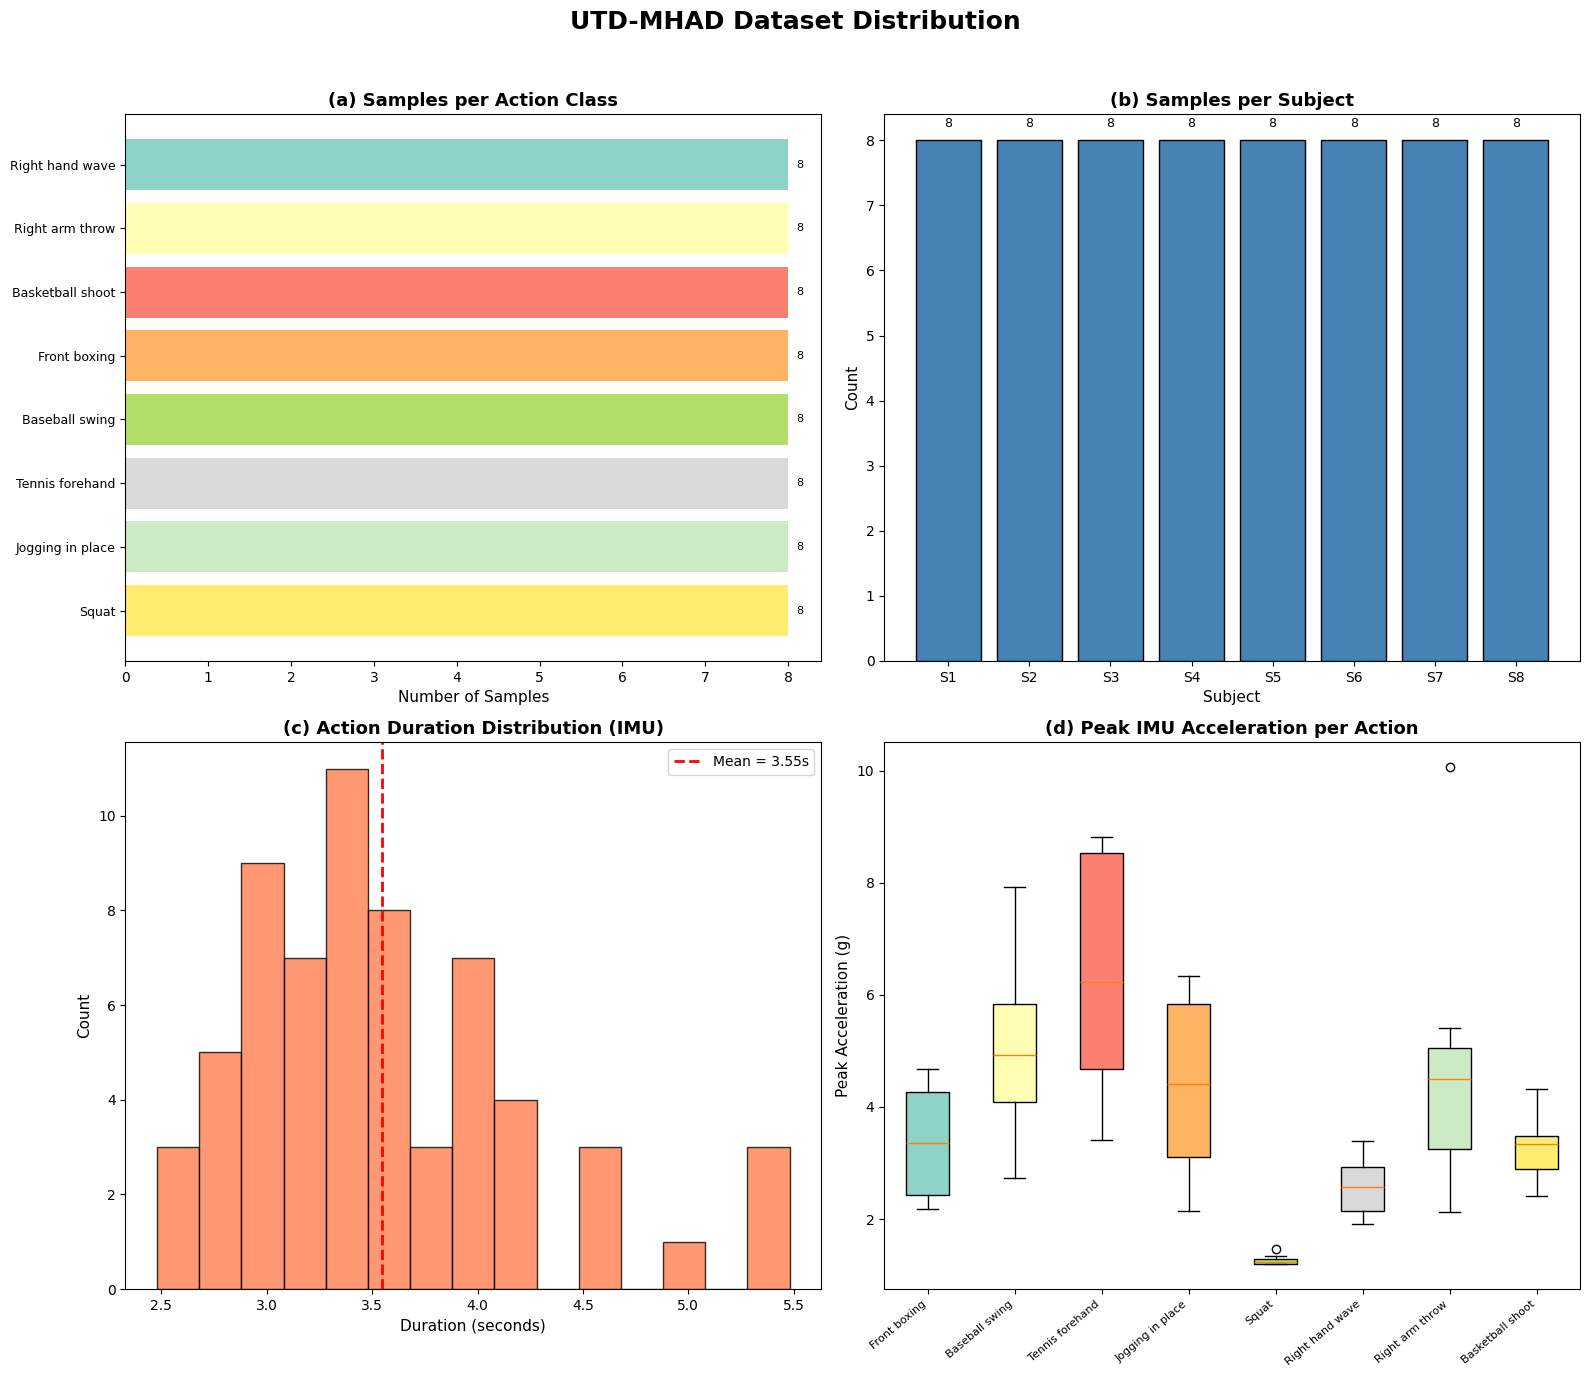

In [ ]:
def visualize_data_distribution(records):
    """
    Visualizes the distribution of the dataset across actions, subjects, and modality statistics.
    Print-friendly: large fonts, no clipped labels, white background.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle('UTD-MHAD Dataset Distribution', fontsize=18, fontweight='bold', y=0.98)
    fig.patch.set_facecolor('white')

    actions  = [r['action'] for r in records]
    subjects = [r['subject'] for r in records]

    # --- (a) Samples per Action Class ---
    ax = axes[0, 0]
    unique_a, counts_a = np.unique(actions, return_counts=True)
    labels_a = [ACTION_LABELS.get(a, str(a)) for a in unique_a]
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_a)))
    ax.barh(range(len(labels_a)), counts_a, color=colors)
    ax.set_yticks(range(len(labels_a)))
    ax.set_yticklabels(labels_a, fontsize=9)
    ax.set_xlabel('Number of Samples', fontsize=11)
    ax.set_title('(a) Samples per Action Class', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    for i, v in enumerate(counts_a):
        ax.text(v + 0.1, i, str(v), va='center', fontsize=8)

    # --- (b) Samples per Subject ---
    ax = axes[0, 1]
    unique_s, counts_s = np.unique(subjects, return_counts=True)
    ax.bar([f'S{s}' for s in unique_s], counts_s, color='steelblue', edgecolor='black')
    ax.set_xlabel('Subject', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('(b) Samples per Subject', fontsize=13, fontweight='bold')
    for i, v in enumerate(counts_s):
        ax.text(i, v + 0.2, str(v), ha='center', fontsize=9)

    # --- (c) IMU Duration Distribution ---
    ax = axes[1, 0]
    durations = [r['iner_raw'].shape[0] / 50.0 for r in records if 'iner_raw' in r]
    ax.hist(durations, bins=15, color='coral', edgecolor='black', alpha=0.8)
    ax.axvline(np.mean(durations), color='red', linestyle='--', lw=2,
               label=f'Mean = {np.mean(durations):.2f}s')
    ax.set_xlabel('Duration (seconds)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('(c) Action Duration Distribution (IMU)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

    # --- (d) Peak Acceleration per Action ---
    ax = axes[1, 1]
    peak_data = {}
    for r in records:
        if 'iner_feat' in r:
            lbl = ACTION_LABELS.get(r['action'], str(r['action']))
            peak_data.setdefault(lbl, []).append(r['iner_feat']['peak_accel'])
    if peak_data:
        labels = list(peak_data.keys())
        bp = ax.boxplot([peak_data[l] for l in labels], vert=True, patch_artist=True)
        for patch, c in zip(bp['boxes'], plt.cm.Set3(np.linspace(0, 1, len(labels)))):
            patch.set_facecolor(c)
        ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
        ax.set_ylabel('Peak Acceleration (g)', fontsize=11)
        ax.set_title('(d) Peak IMU Acceleration per Action', fontsize=13, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('1_data_distribution.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close('all')


visualize_data_distribution(records)

# Samples

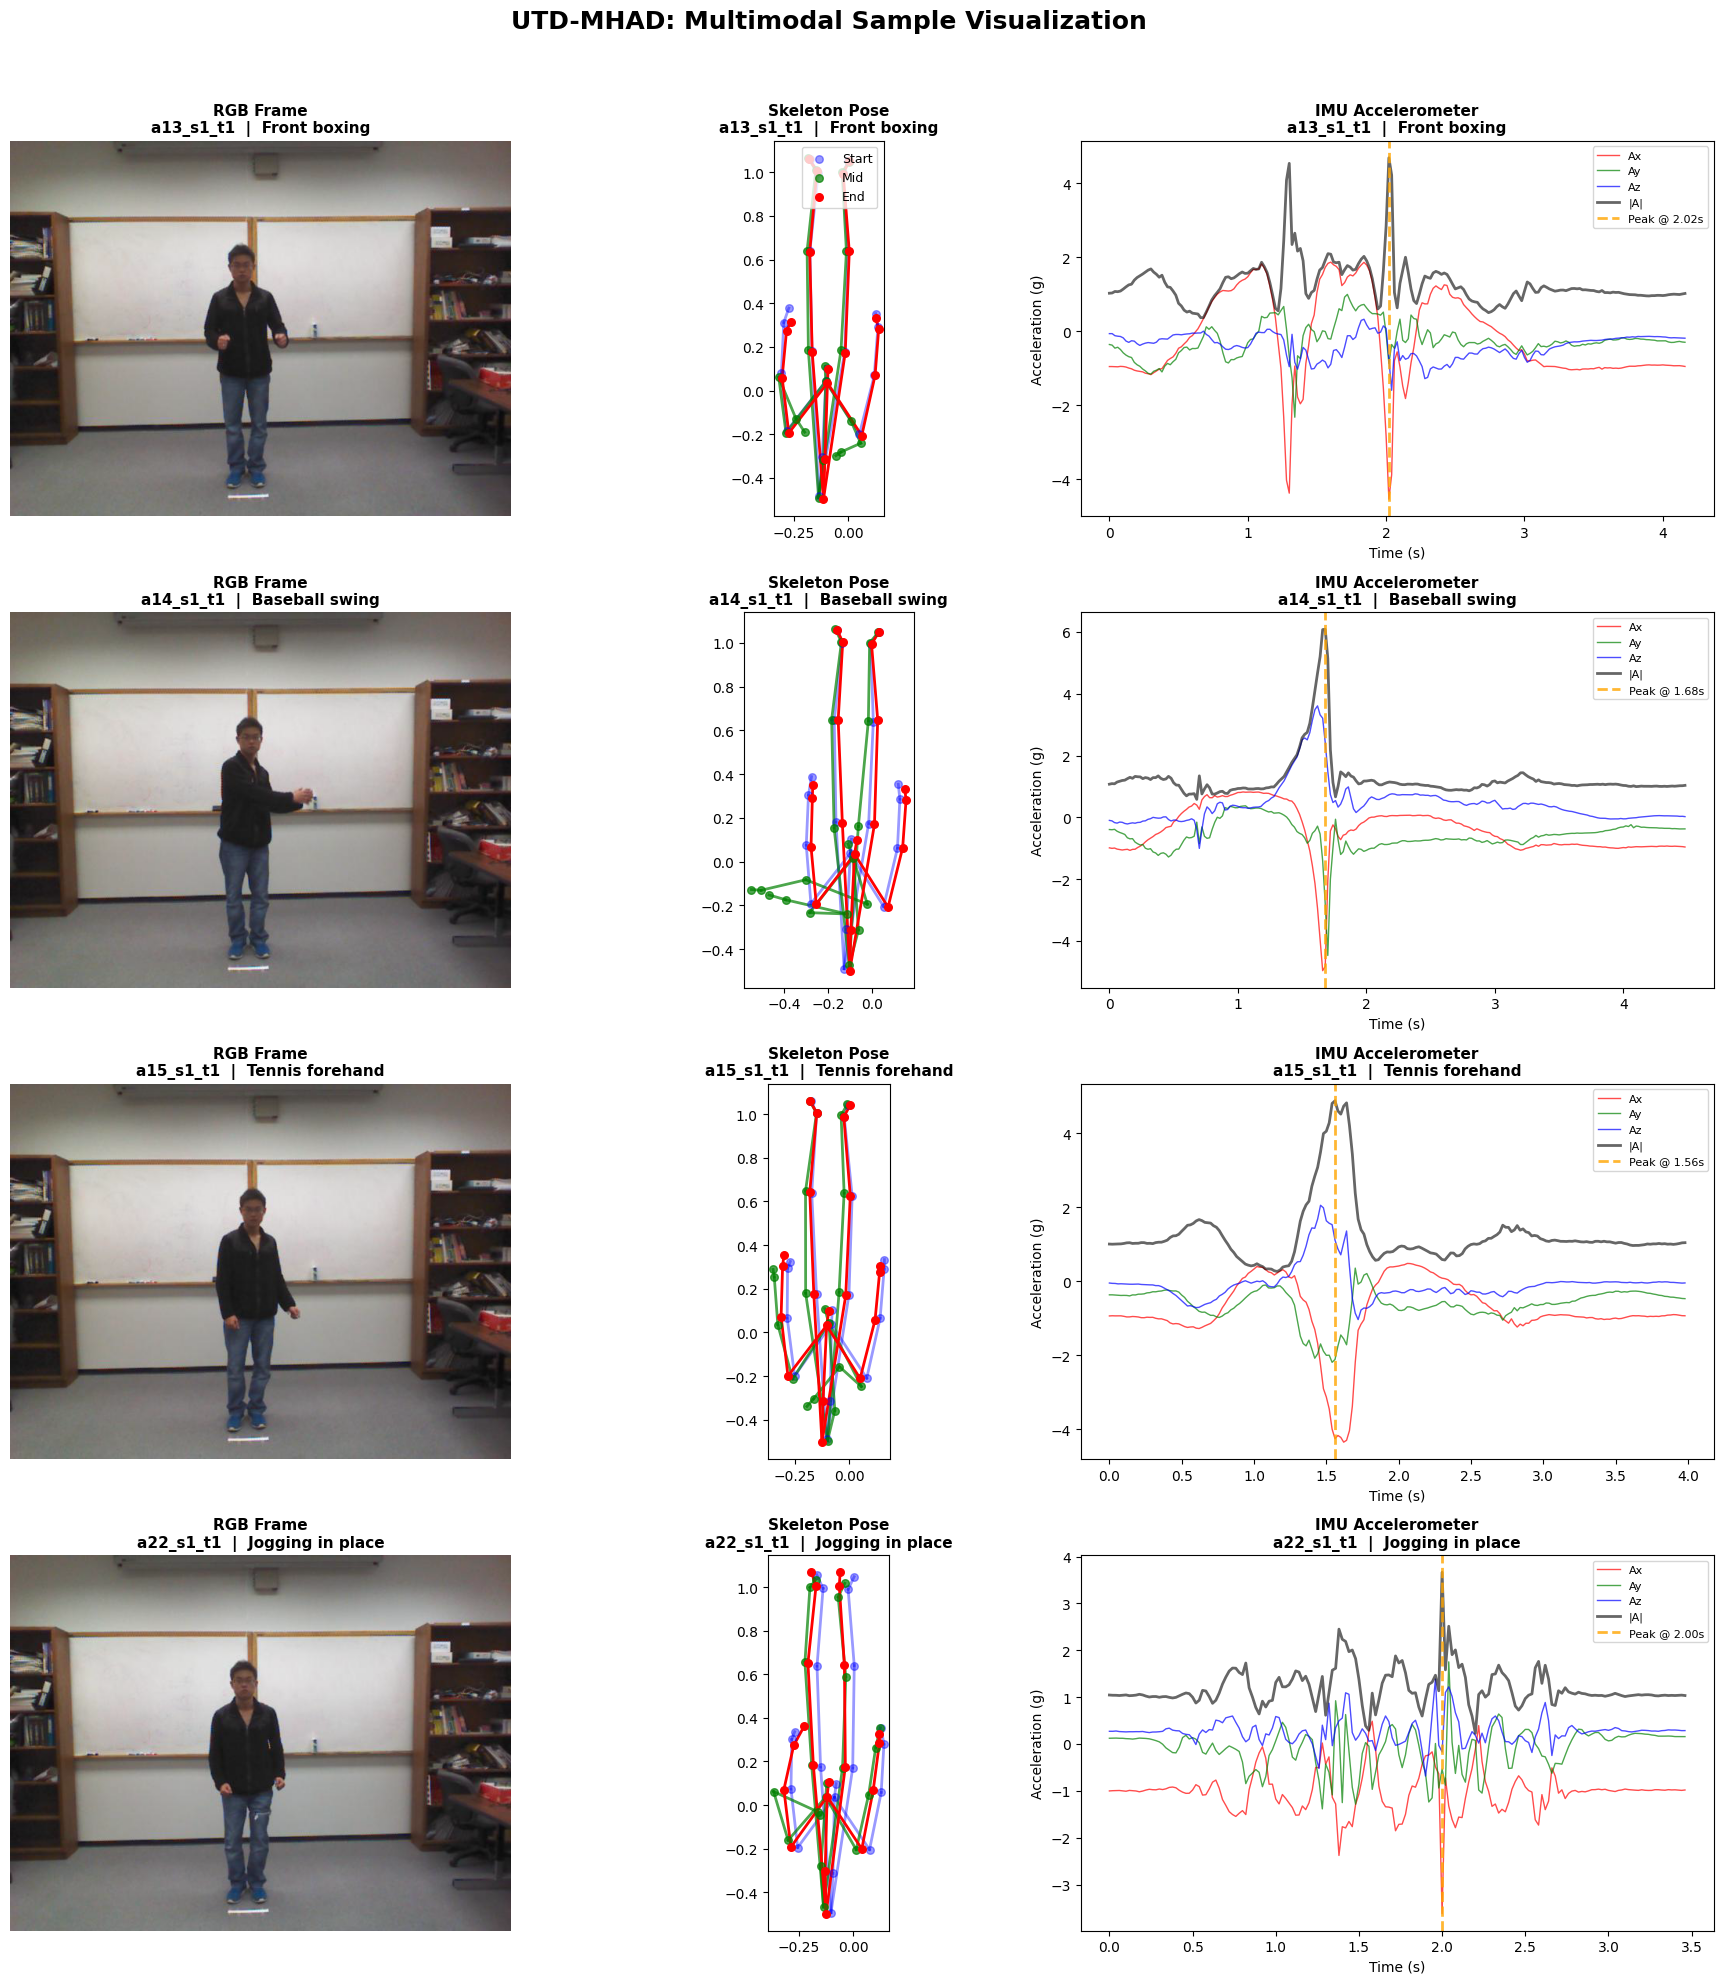

In [ ]:
def visualize_samples(records, num_samples=4):
    """
    Visualizes individual samples showing all three modalities side by side.
    Print-friendly: 4 rows × 3 columns, large fonts, white bg.
    """
    # Pick diverse samples from different actions
    selected = []
    seen = set()
    for r in records:
        if r['action'] not in seen and 'iner_raw' in r:
            selected.append(r)
            seen.add(r['action'])
        if len(selected) >= num_samples:
            break

    n = len(selected)
    fig, axes = plt.subplots(n, 3, figsize=(18, 5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    fig.suptitle('UTD-MHAD: Multimodal Sample Visualization',
                 fontsize=18, fontweight='bold', y=0.99)
    fig.patch.set_facecolor('white')

    for i, rec in enumerate(selected):
        title = f"{rec['prefix']}  |  {rec['label']}"

        # ---- Column 1: RGB Frame ----
        ax = axes[i, 0]
        if 'rgb_path' in rec:
            frames, _ = extract_rgb_frames(rec['rgb_path'], max_frames=5, sample_rate=5)
            if frames:
                ax.imshow(frames[len(frames)//2])
        ax.set_title(f'RGB Frame\n{title}', fontsize=11, fontweight='bold')
        ax.axis('off')

        # ---- Column 2: Skeleton Pose ----
        ax = axes[i, 1]
        if 'skel_raw' in rec:
            skel = rec['skel_raw']
            T = skel.shape[0]
            n_j = min(skel.shape[1], 20)
            for t_idx, color, alpha, lbl in [
                (0, 'blue', 0.4, 'Start'),
                (T//2, 'green', 0.7, 'Mid'),
                (T-1, 'red', 1.0, 'End')
            ]:
                if t_idx >= T: continue
                pose = skel[t_idx]
                ax.scatter(pose[:n_j, 0], -pose[:n_j, 1], c=color, s=30, alpha=alpha, zorder=5, label=lbl)
                for c1, c2 in SKELETON_CONNECTIONS:
                    if c1 < n_j and c2 < n_j:
                        ax.plot([pose[c1,0], pose[c2,0]], [-pose[c1,1], -pose[c2,1]],
                                color=color, alpha=alpha, linewidth=2)
            ax.set_aspect('equal')
            if i == 0: ax.legend(fontsize=9, loc='upper right')
        ax.set_title(f'Skeleton Pose\n{title}', fontsize=11, fontweight='bold')

        # ---- Column 3: IMU Signals ----
        ax = axes[i, 2]
        if 'iner_raw' in rec:
            raw = rec['iner_raw']
            t = np.arange(raw.shape[0]) / 50.0
            ax.plot(t, raw[:, 0], 'r-', alpha=0.7, lw=1, label='Ax')
            ax.plot(t, raw[:, 1], 'g-', alpha=0.7, lw=1, label='Ay')
            ax.plot(t, raw[:, 2], 'b-', alpha=0.7, lw=1, label='Az')
            amag = np.linalg.norm(raw[:, :3], axis=1)
            ax.plot(t, amag, 'k-', lw=2, alpha=0.6, label='|A|')
            peak = np.argmax(amag)
            ax.axvline(t[peak], color='orange', ls='--', lw=2, alpha=0.8,
                       label=f'Peak @ {t[peak]:.2f}s')
            ax.legend(fontsize=8, loc='upper right')
        ax.set_title(f'IMU Accelerometer\n{title}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Time (s)', fontsize=10)
        ax.set_ylabel('Acceleration (g)', fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig('2_sample_visualization.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close('all')


visualize_samples(records, num_samples=4)

# Input Distribution

Feature matrix builder ready.


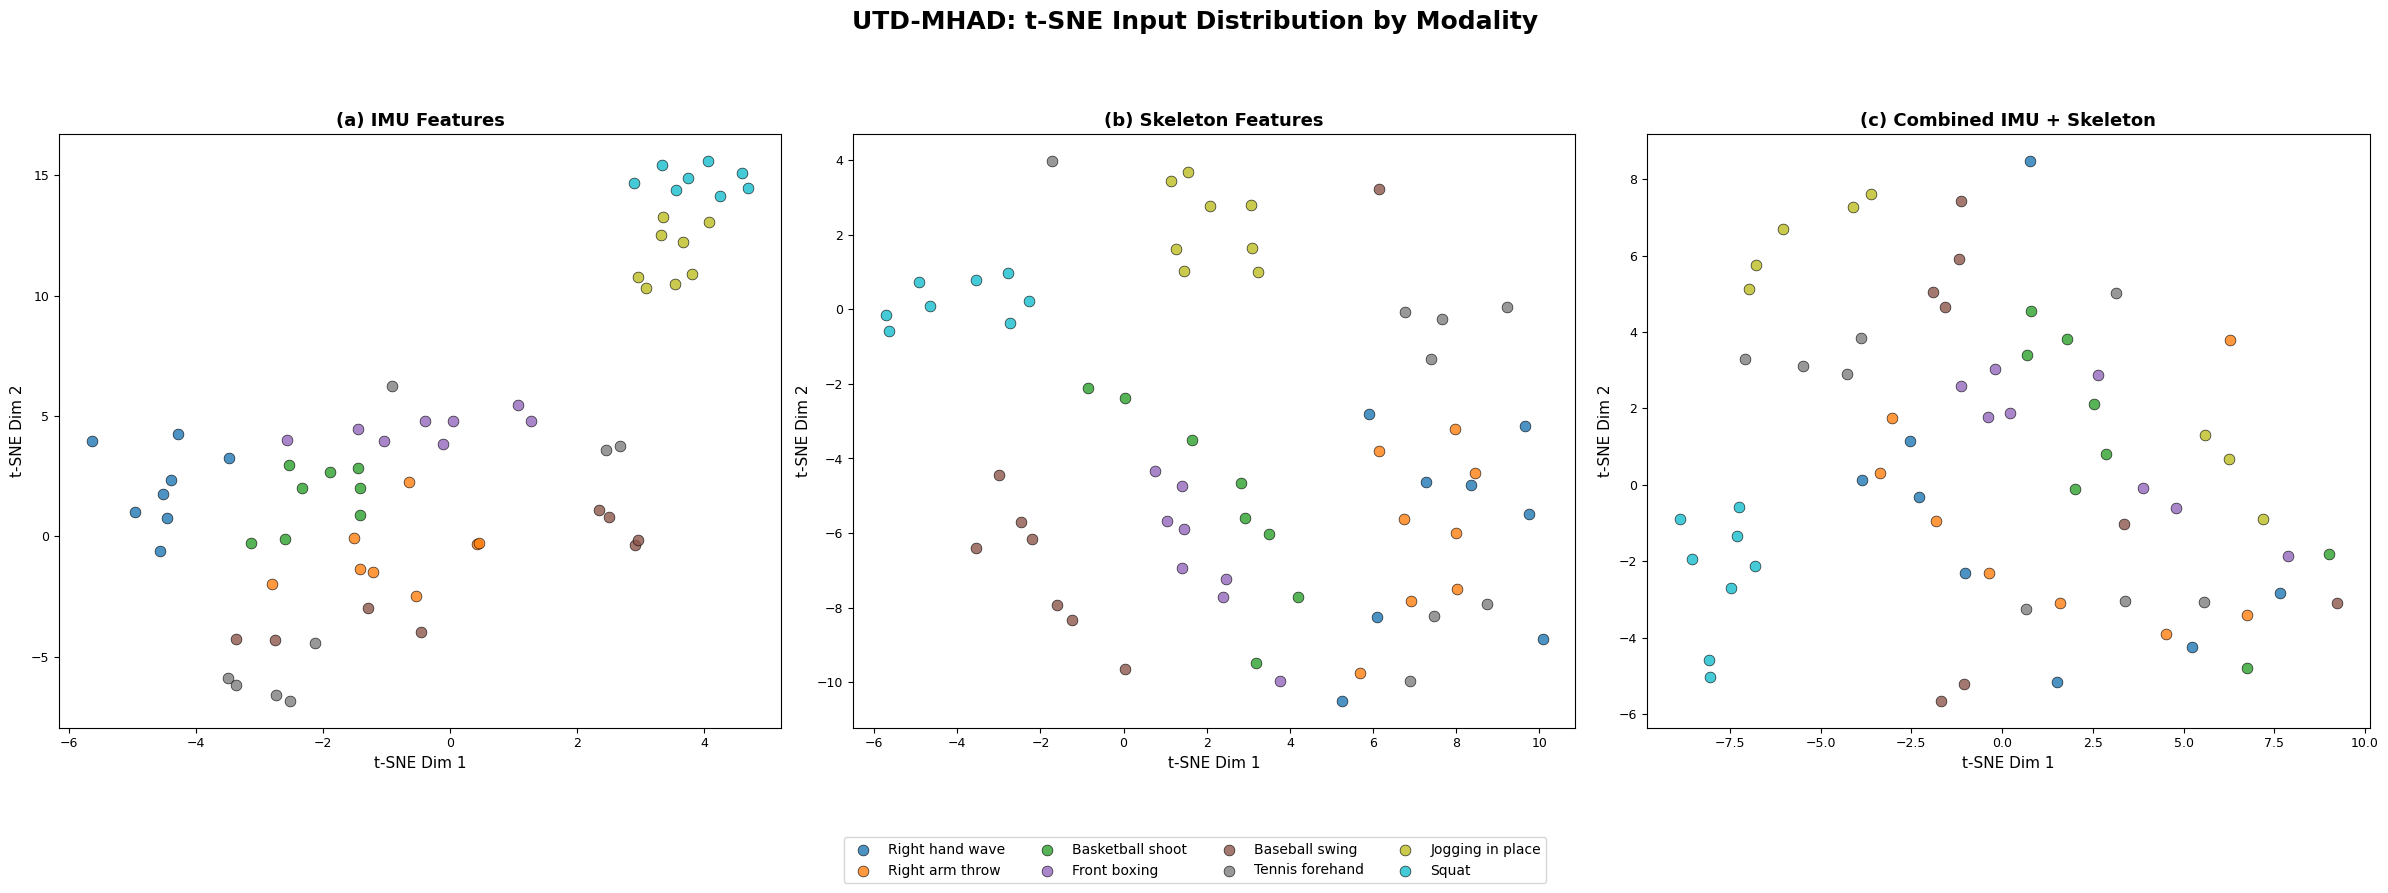

In [ ]:
def build_feature_matrix(records, modality='inertial'):
    """
    Build a 2D feature matrix from records for dimensionality reduction.

    Args:
        records: list of record dicts
        modality: 'inertial', 'skeleton', or 'combined'

    Returns:
        X: (N, D) feature matrix
        y: (N,) action labels
    """
    features, labels = [], []

    for r in records:
        if modality == 'inertial' and 'iner_feat' in r:
            f = r['iner_feat']
            vec = np.array([
                f['peak_accel'], f['mean_accel'], f['std_accel'],
                f['peak_gyro'],  f['mean_gyro'],  f['std_gyro'],
                f['peak_jerk'],
                *np.mean(f['accel'], axis=0), *np.std(f['accel'], axis=0),
                *np.mean(f['gyro'],  axis=0), *np.std(f['gyro'],  axis=0),
            ])
            features.append(vec)
            labels.append(r['action'])

        elif modality == 'skeleton' and 'skel_feat' in r:
            features.append(r['skel_feat']['feature_vector'])
            labels.append(r['action'])

        elif modality == 'combined' and 'iner_feat' in r and 'skel_feat' in r:
            f = r['iner_feat']
            iner_vec = np.array([
                f['peak_accel'], f['mean_accel'], f['std_accel'],
                f['peak_gyro'],  f['mean_gyro'],  f['std_gyro'], f['peak_jerk'],
            ])
            skel_vec = r['skel_feat']['feature_vector'][:40]
            features.append(np.concatenate([iner_vec, skel_vec]))
            labels.append(r['action'])

    if not features:
        return None, None
    return np.array(features), np.array(labels)

print('Feature matrix builder ready.')

def visualize_input_distribution(records):
    """
    Visualizes input distribution using t-SNE for each modality.
    Print-friendly: large figure, readable legend, white background.
    """
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fig.suptitle('UTD-MHAD: t-SNE Input Distribution by Modality',
                 fontsize=18, fontweight='bold', y=1.02)
    fig.patch.set_facecolor('white')

    configs = [
        ('inertial', '(a) IMU Features'),
        ('skeleton', '(b) Skeleton Features'),
        ('combined', '(c) Combined IMU + Skeleton'),
    ]

    for idx, (mod, title) in enumerate(configs):
        ax = axes[idx]
        X, y = build_feature_matrix(records, modality=mod)

        if X is None or len(X) < 10:
            ax.text(0.5, 0.5, f'Not enough data for {mod}',
                    transform=ax.transAxes, ha='center', fontsize=14)
            ax.set_title(title, fontsize=13, fontweight='bold')
            continue

        # Standardize
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(np.nan_to_num(X))

        # t-SNE
        perp = min(30, max(5, len(X) // 4))
        tsne = TSNE(n_components=2, perplexity=perp, max_iter=1000, random_state=42)
        X_tsne = tsne.fit_transform(X_scaled)

        # Plot each action
        unique_actions = np.unique(y)
        cmap = plt.cm.get_cmap('tab10', len(unique_actions))
        for i, a in enumerate(unique_actions):
            mask = y == a
            lbl = ACTION_LABELS.get(a, str(a))
            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                       c=[cmap(i)], label=lbl, s=60, alpha=0.8,
                       edgecolors='black', linewidth=0.5)

        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('t-SNE Dim 1', fontsize=11)
        ax.set_ylabel('t-SNE Dim 2', fontsize=11)
        ax.tick_params(labelsize=9)

    # Shared legend at the bottom
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4,
              fontsize=10, bbox_to_anchor=(0.5, -0.08),
              frameon=True, fancybox=True)

    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.savefig('3_tsne_input_distribution.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close('all')


visualize_input_distribution(records)

# Additional Visualizations (Creative Extensions)

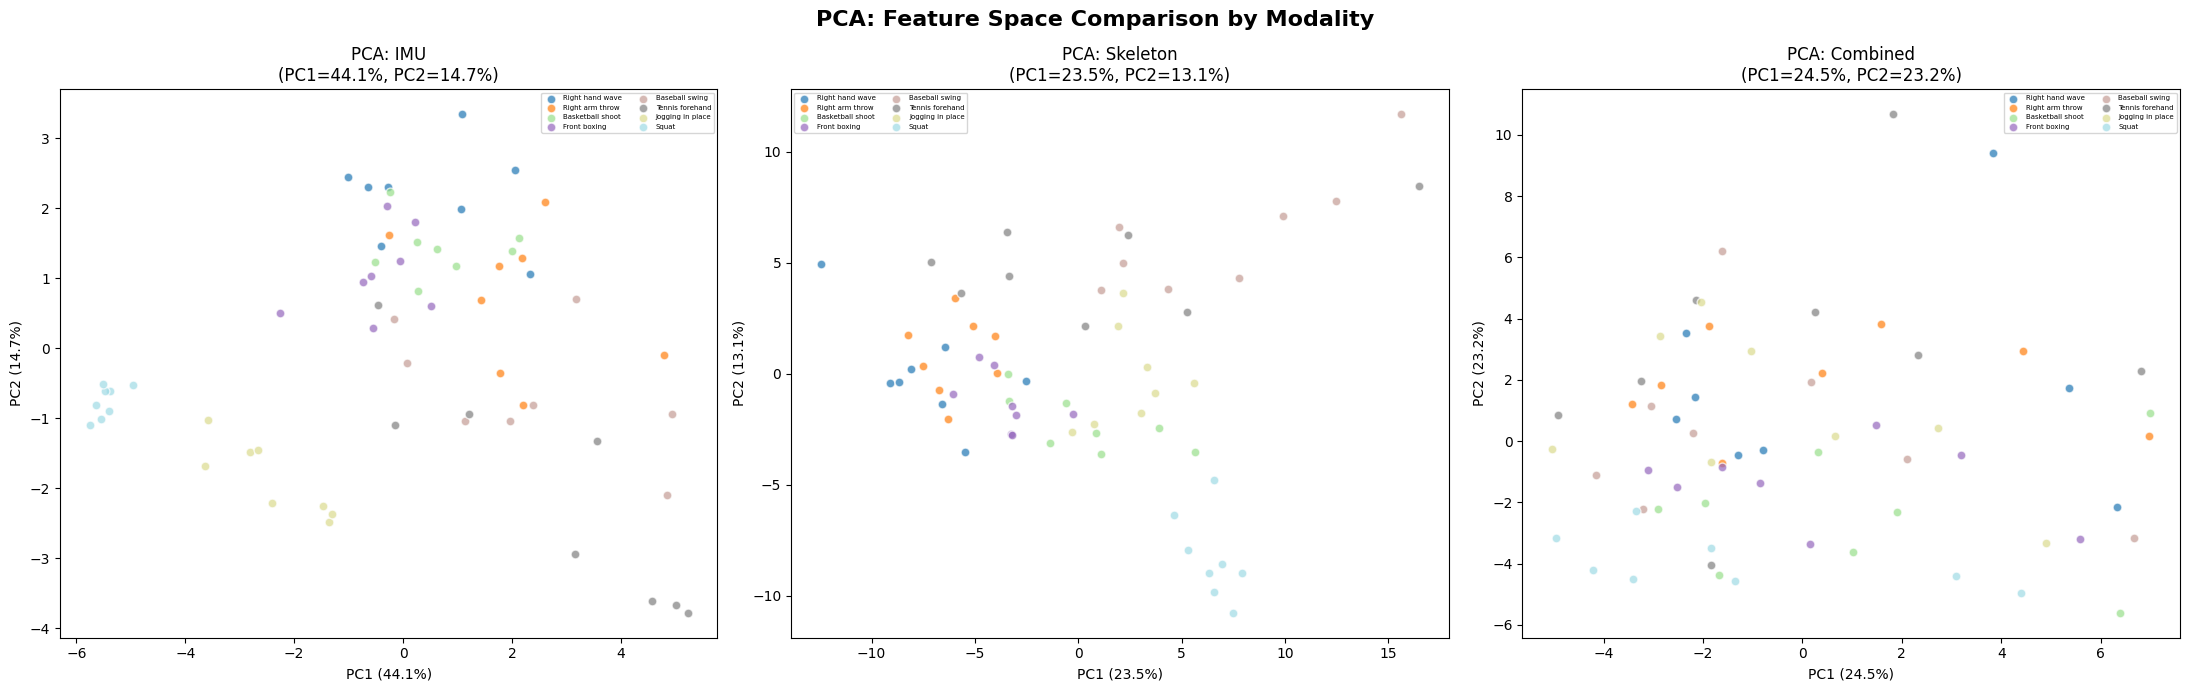

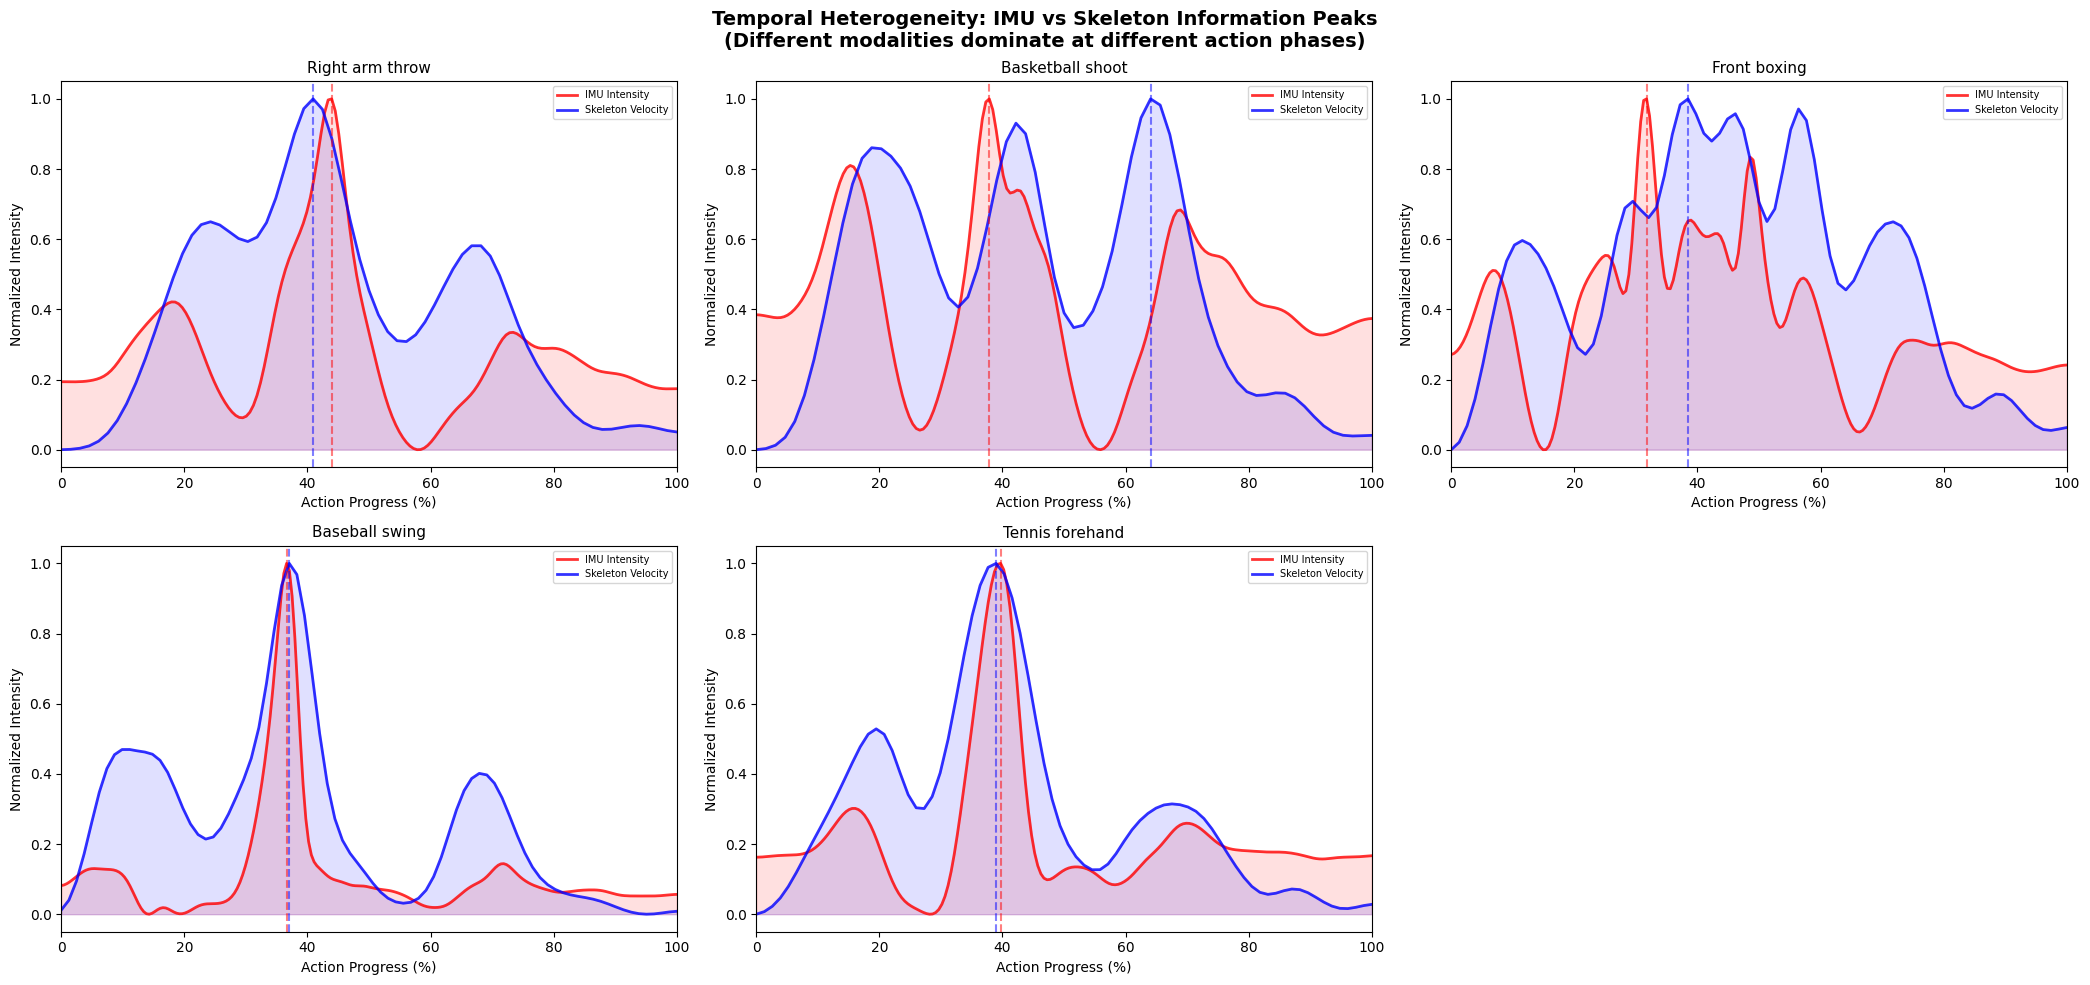

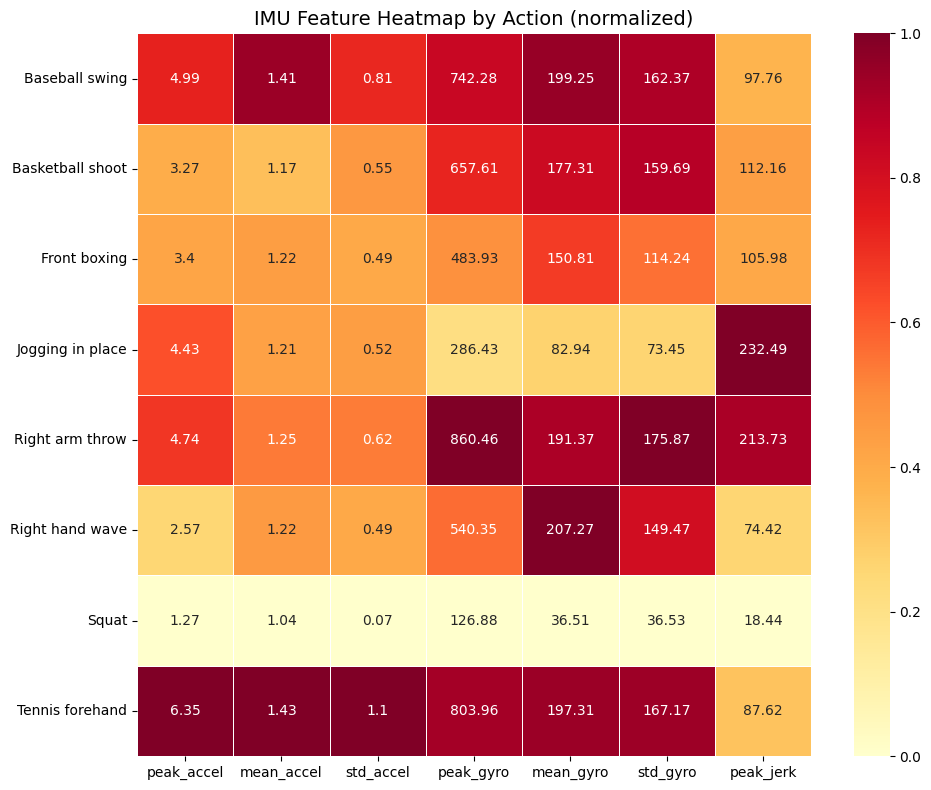

In [ ]:
# ---- (A) PCA comparison: variance explained per modality ----

def visualize_pca_comparison(records):
    """PCA on each modality's features — shows how much variance the first 2 PCs capture."""
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    fig.suptitle('PCA: Feature Space Comparison by Modality', fontsize=16, fontweight='bold')

    for idx, (mod, title) in enumerate([
        ('inertial', 'IMU'), ('skeleton', 'Skeleton'), ('combined', 'Combined')
    ]):
        ax = axes[idx]
        X, y = build_feature_matrix(records, modality=mod)
        if X is None or len(X) < 5:
            ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center')
            continue

        X_s = StandardScaler().fit_transform(np.nan_to_num(X))
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_s)

        unique_a = np.unique(y)
        cmap = plt.cm.get_cmap('tab20', len(unique_a))
        for i, a in enumerate(unique_a):
            mask = y == a
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[cmap(i)],
                       label=ACTION_LABELS.get(a, str(a))[:22], s=40, alpha=0.7, edgecolors='white')

        v = pca.explained_variance_ratio_
        ax.set_title(f'PCA: {title}\n(PC1={v[0]:.1%}, PC2={v[1]:.1%})')
        ax.set_xlabel(f'PC1 ({v[0]:.1%})')
        ax.set_ylabel(f'PC2 ({v[1]:.1%})')
        ax.legend(fontsize=5, ncol=2)

    plt.tight_layout()
    plt.savefig('4_pca_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')

visualize_pca_comparison(records)

# ---- (B) Temporal Heterogeneity: IMU vs Skeleton information peaks ----
# This is the KEY plot for our Phase-Aware project proposal:
# It shows that IMU peaks during impact while skeleton velocity peaks during preparation.

from scipy.ndimage import gaussian_filter1d

def visualize_temporal_heterogeneity(records):
    """Show that IMU and Vision/Skeleton have different temporal information peaks."""
    # Pick actions with clear explosive phases
    target_actions = [5, 7, 13, 14, 15, 17]  # throw, basketball, boxing, baseball, tennis, serve
    selected = []
    for a in target_actions:
        for r in records:
            if r['action'] == a and 'iner_feat' in r and 'skel_feat' in r:
                selected.append(r)
                break
    if not selected:
        # fallback
        selected = [r for r in records if 'iner_feat' in r and 'skel_feat' in r][:4]

    n = min(len(selected), 6)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 5*rows))
    fig.suptitle('Temporal Heterogeneity: IMU vs Skeleton Information Peaks\n'
                 '(Different modalities dominate at different action phases)',
                 fontsize=14, fontweight='bold')
    if rows == 1:
        axes = axes.reshape(1, -1)

    for i, rec in enumerate(selected[:n]):
        ax = axes[i // cols, i % cols]

        # Normalize both signals to 0–100% action progress
        accel_mag = rec['iner_feat']['accel_mag']
        t_imu = np.linspace(0, 100, len(accel_mag))

        total_speed = rec['skel_feat']['joint_speeds'].mean(axis=1)
        t_skel = np.linspace(0, 100, len(total_speed))

        # Smooth
        a_smooth = gaussian_filter1d(accel_mag, sigma=3)
        s_smooth = gaussian_filter1d(total_speed, sigma=2)

        # Normalize to [0, 1]
        a_norm = (a_smooth - a_smooth.min()) / (a_smooth.max() - a_smooth.min() + 1e-8)
        s_norm = (s_smooth - s_smooth.min()) / (s_smooth.max() - s_smooth.min() + 1e-8)

        ax.plot(t_imu, a_norm, 'r-', lw=2, label='IMU Intensity', alpha=0.8)
        ax.plot(t_skel, s_norm, 'b-', lw=2, label='Skeleton Velocity', alpha=0.8)
        ax.fill_between(t_imu, a_norm, alpha=0.12, color='red')
        ax.fill_between(t_skel, s_norm, alpha=0.12, color='blue')

        imu_peak = t_imu[np.argmax(a_norm)]
        skel_peak = t_skel[np.argmax(s_norm)]
        ax.axvline(imu_peak, color='red', ls='--', alpha=0.5)
        ax.axvline(skel_peak, color='blue', ls='--', alpha=0.5)

        ax.set_title(rec['label'], fontsize=11)
        ax.set_xlabel('Action Progress (%)')
        ax.set_ylabel('Normalized Intensity')
        ax.legend(fontsize=7)
        ax.set_xlim(0, 100)

    # Hide unused subplots
    for j in range(n, rows * cols):
        axes[j // cols, j % cols].axis('off')

    plt.tight_layout()
    plt.savefig('5_temporal_heterogeneity.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')

visualize_temporal_heterogeneity(records)


# ---- (C) Correlation heatmap: IMU features across actions ----

def visualize_imu_heatmap(records):
    """Heatmap of mean IMU feature values per action class."""
    feat_names = ['peak_accel', 'mean_accel', 'std_accel', 'peak_gyro', 'mean_gyro', 'std_gyro', 'peak_jerk']
    action_feats = {}
    for r in records:
        if 'iner_feat' in r:
            lbl = r['label'][:20]
            if lbl not in action_feats:
                action_feats[lbl] = {fn: [] for fn in feat_names}
            for fn in feat_names:
                action_feats[lbl][fn].append(r['iner_feat'][fn])

    if not action_feats:
        print('No IMU data for heatmap.')
        return

    # Build matrix
    labels = sorted(action_feats.keys())
    matrix = np.array([[np.mean(action_feats[l][fn]) for fn in feat_names] for l in labels])

    # Normalize columns
    matrix_norm = (matrix - matrix.min(axis=0)) / (matrix.max(axis=0) - matrix.min(axis=0) + 1e-8)

    fig, ax = plt.subplots(figsize=(10, max(8, len(labels)*0.4)))
    sns.heatmap(matrix_norm, annot=np.round(matrix, 2), fmt='', xticklabels=feat_names,
                yticklabels=labels, cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('IMU Feature Heatmap by Action (normalized)', fontsize=14)
    plt.tight_layout()
    plt.savefig('6_imu_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')

visualize_imu_heatmap(records)

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?

    We plan to use Macro F1-Score as our primary metric. Since UTD-MHAD has 27 action classes and some actions are visually similar (e.g., "draw circle CW" vs "draw circle CCW"), we need a metric that captures per-class precision and recall equally. Macro F1 treats all classes with equal weight, revealing if the model fails on specific hard-to-distinguish actions rather than hiding poor performance behind high accuracy on easy classes.


2. Are there any other metrics that could be used here or that you considered?

    Yes， Top-1 Accuracy (simpler but doesn't show per-class weaknesses), Confusion Matrix (good for error analysis but not a single summary number), and Top-K Accuracy (relevant when similar actions exist, but less standard for this dataset).

3. List out the pros and cons of the evaluation metrics you decided to go with.

    Pros: Balances precision and recall, treats all 27 classes equally, exposes weaknesses on hard classes, standard in multi-class settings
    Cons: Harder to interpret than accuracy, a single number still hides per-class detail, sensitive to classes with very few test samples

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

In [ ]:
def evaluation_metric(predictions, ground_truths):
    """
    Computes Macro F1-Score: the unweighted mean of per-class F1 scores.
    Each class is treated equally regardless of its sample count.

    Args:
        predictions: list of predicted class labels
        ground_truths: list of true class labels

    Returns:
        float: macro F1 score in [0, 1]
    """
    predictions = list(predictions)
    ground_truths = list(ground_truths)

    if len(ground_truths) == 0:
        raise ValueError("Issue reading ground truths/No ground truths provided!")

    all_classes = sorted(set(ground_truths) | set(predictions))
    f1_scores = []

    for cls in all_classes:
        tp = sum(1 for p, g in zip(predictions, ground_truths) if p == cls and g == cls)
        fp = sum(1 for p, g in zip(predictions, ground_truths) if p == cls and g != cls)
        fn = sum(1 for p, g in zip(predictions, ground_truths) if p != cls and g == cls)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1_scores.append(f1)

    return sum(f1_scores) / len(f1_scores)


In [ ]:
# Quick test
np.random.seed(42)

# Simulate 200 samples across 27 action classes, ~80% correct
gt = np.random.randint(1, 28, size=200)
preds = gt.copy()
flip = np.random.random(200) > 0.8
preds[flip] = np.random.randint(1, 28, size=flip.sum())

print(f"Macro F1-Score: {evaluation_metric(preds, gt):.4f}")
print(f"Perfect score:  {evaluation_metric(gt, gt):.4f}")

Macro F1-Score: 0.8029
Perfect score:  1.0000


(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

    **Prompt**: "Analyze the sentiment of the restaurant review provided below. Classify it strictly as either 'Positive' or 'Negative'. Output ONLY the single word label.

    Review: 'This place stinks, the service was awful and the food was not cooked. I will never come back here!'"

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

    **Prompt**: "Observe the facial expression in the dataset image and identify the primary emotion expressed. Choose strictly from the following three categories: [Angry, Sad, Happy]. Return only the category name as a single word.

    Image input: [Face Image]"

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

    **Prompt**: "Extract the following information from the paragraph below and format the output strictly as a JSON object with the keys 'name', 'destination', and 'activity'.

    Paragraph: 'The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there.'

    Output Format:
    {
    'name': '...',
    'destination': '...',
    'activity': '...'
    }"

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [ ]:
# BONUS CODE HERE


(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.

    The most intriguing part of this assignment was the creative brainstorming process regarding human cognition. Initially, we aimed to study and predict "subconscious friction"—the hidden cognitive resistance occurring during human decision-making. Although we eventually pivoted our goal because such a high-level psychological state is extremely difficult to quantify and find specific datasets for, the exploration of how neuro-signals might conflict with physical actions remains the most fascinating topic to us.

2. A challenging aspect that you did not expect to deal with and what insights you used to address it.

    An unexpected challenge was the technical "Link Rot" and data obsolescence of classic academic datasets. While searching for the Berkeley MHAD dataset, we found that many original university servers from the early 2010s are no longer active. To address this, we used the insight of "Academic Mirroring," locating verified backups on platforms like OpenDataLab and GitHub. This taught us that data persistence is a major hurdle in multimodal research, and leveraging community-maintained repositories is essential for reproducibility.

3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

    Overall, the UTD-MHAD dataset is high-quality and aligns well with our current project needs. Its greatest strength is the synchronization between vision-based modalities (RGB/Skeleton) and inertial modalities (IMU), which allows us to analyze movement from both an external and internal perspective. However, its primary deficiency is the lack of EMG (Electromyography) data. Having EMG would have allowed us to observe neural activation patterns before physical movement began, providing a much richer "neural-to-physical" multimodal mapping.


There is no specific right answer we are looking for, answer how you think!